In [1]:
import numpy as np
import cv2
import time
import matplotlib.pyplot as plt
from PIL import Image
import os

In [2]:
def get_color_map_list(num_classes):
    """
    Returns the color map for visualizing the segmentation mask,
    which can support arbitrary number of classes.
    Args:
        num_classes (int): Number of classes.
    Returns:
        (list). The color map.
    """

    num_classes += 1
    color_map = num_classes * [0, 0, 0]
    for i in range(0, num_classes):
        j = 0
        lab = i
        while lab:
            color_map[i * 3] |= (((lab >> 0) & 1) << (7 - j))
            color_map[i * 3 + 1] |= (((lab >> 1) & 1) << (7 - j))
            color_map[i * 3 + 2] |= (((lab >> 2) & 1) << (7 - j))
            j += 1
            lab >>= 3
    color_map = color_map[3:]
    return color_map

color_map = get_color_map_list(256)

In [3]:
source_imgs_dir = r'C:\Users\hp\Desktop\tc_data\150x70\rust4x\gtFine'
new_imgs_save_dir = r'C:\Users\hp\Desktop\tc_data\150x70\rust2x\gtFine'
source_imgs_name_lists = os.listdir(source_imgs_dir)
imgs_name = []
for item in source_imgs_name_lists:
    if item.split('.')[-1] in ['jpg', 'png', 'bmp', 'jpeg']:
        imgs_name.append(item)

In [4]:
# 定大小放缩
for i, img_name in enumerate(imgs_name):
    path = os.path.join(source_imgs_dir, img_name)
    label = Image.open(path)
    label_re = label.resize(size=(1096, 512)) # (width, height),(cols, rows)
    
    save_name = img_name
    # save_name = img_name.split('.')[0]+'.jpg'
    save_path = os.path.join(new_imgs_save_dir, save_name)
    label_re.putpalette(color_map)
    label_re.save(save_path)

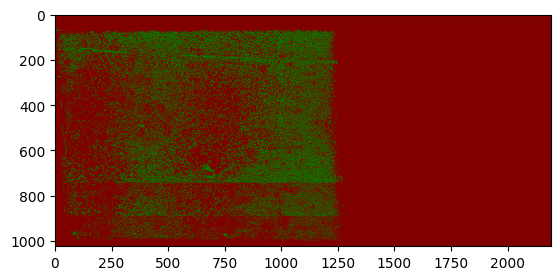

In [3]:
path = r"C:\Users\hp\Desktop\low_angle\crop2\full\2.png"
label = Image.open(path)

label_re = label.resize(size=(1096*2, 512*2))
plt.imshow(label_re)

In [4]:
label_re.putpalette(color_map)

save_path= r"C:\Users\hp\Desktop\\a.png"
label_re.save(save_path)
